In [2]:
import numpy as np
import casadi
from plan_multi_bicycle import MPC_CBF_Bicycle, dm_to_array, animate
%load_ext autoreload
%autoreload 2

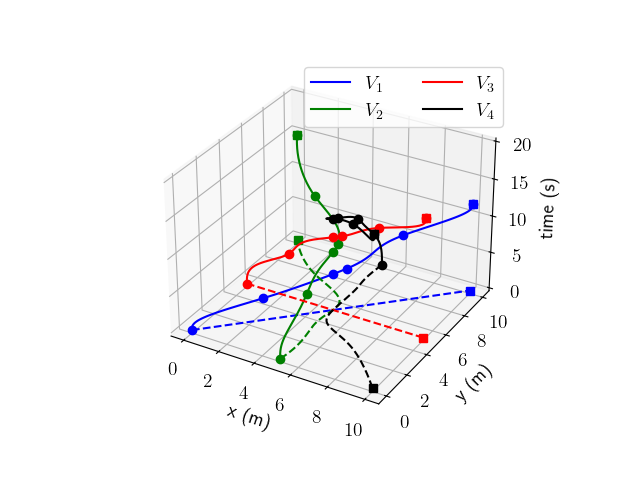

In [3]:
import numpy as np
import minsnap_trajectories as ms
import matplotlib.pyplot as plt
from plan_poly import plan_poly_traj
import ipympl
%matplotlib widget

fig = plt.figure()
ax = plt.axes(projection='3d')


## waypoint = [t , p_x , p_y]
aircraft_1_wp = np.array([[0.0, 0.0, 0.0],
                          [3.0, 2.5, 2.5],
                          [5.0, 5.0, 5.0],
                          [5.5, 5.5, 5.5],
                          [9.0, 7.5, 7.5],
                          [12.0, 10.0, 10.0]
                          ])

aircraft_2_wp = np.array([[0.0, 5.0, 0.0],
                          [5.5, 5.0, 2.5],
                          [8.0, 5.0, 5.0],
                          [8.5, 5.0, 5.5],
                          [11.0, 2.5, 7.5],
                          [15.0, 0.0, 10.0]
                          ])
aircraft_3_wp = np.array([[0.0, 0.0, 5.0],
                          [6.0, 2.5, 5.0],
                          [10.0, 5.0, 5.0],
                          [10.5, 5.5, 5.0],
                          [13.0, 7.5, 5.0],
                          [16.0, 10.0, 5.0]
                          ])

aircraft_4_wp = np.array([[0.0, 5.0, 10.0],
                          [9.5, 5.0, 7.5],
                          [12.0, 5.0, 5.5],
                          [12.5, 5.0, 5.0],
                          [16.5, 7.5, 2.5],
                          [20.0, 10.0, 0.0]
                          ])

wps = np.array([aircraft_1_wp, aircraft_2_wp, aircraft_3_wp, aircraft_4_wp])
lbls= ['$V_1$', '$V_2$', '$V_3$', '$V_4$']
colors = ['b', 'g', 'r', 'k']
wp_start = ['o', 'o', 'o', 'o']
wp_goal = ['s', 's', 's', 's']

n_agents = 4
trajs = []
for i in range(n_agents):
    boundary_cdn = []
    for j in range(wps[i].shape[0]):
        boundary_cdn += [
            ms.Waypoint(
                time=wps[i][j,0],
                position=wps[i][j,1:3],
            )
        ]
 
    t, pos, vel = plan_poly_traj(boundary_cdn, wps[i][-1,0], 0.1)
    ax.plot3D(pos[:, 0], pos[:, 1], t, color = colors[i], label=lbls[i])
    ax.plot(pos[:, 0], pos[:, 1], '--', color = colors[i])
    
    position_waypoints = np.array([it.position for it in boundary_cdn])
    time_waypoints = np.array([it.time for it in boundary_cdn])
    ax.plot(
        position_waypoints[:, 0],
        position_waypoints[:, 1],
        time_waypoints,
        wp_start[i],
        color = colors[i]
    )
    ax.plot(
        position_waypoints[-1, 0],
        position_waypoints[-1, 1],
        wp_goal[i],
        color = colors[i]
    )
    ax.plot(
        position_waypoints[-1, 0],
        position_waypoints[-1, 1],
        time_waypoints[-1],
        wp_goal[i],
        color = colors[i]
    )
    traj = {}
    traj['x'] = pos[:, 0]
    traj['y'] = pos[:, 1]
    traj['theta'] = np.arctan2(
                vel[:, 1], vel[:, 0]
            )
    traj['v'] = np.linalg.norm(vel[:,:], axis = 1)

    trajs.append(traj)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("time (s)")
ax.legend(loc="upper right", ncol = 2)
plt.grid()
plt.show()

100%|██████████| 200/200 [00:09<00:00, 20.48it/s]

avg_vel_var 0.31485457578015935
avg_acc_var 0.11518846025111901


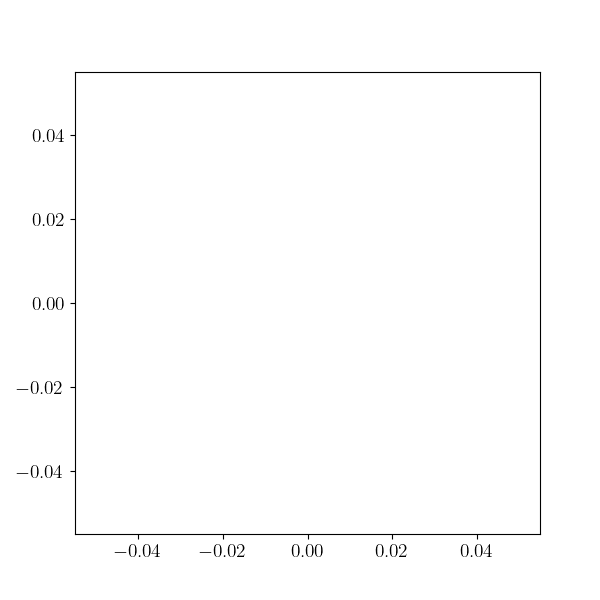

In [5]:
# Consider all homogenous agents with identical parameters
Q_x = 10
Q_y = 10
Q_theta = 5
Q_v = 5
R_a = 0.01
R_delta = 0.01

dt = 0.1
N = 15

L = 1
a_lim = [-0.5, 0.5]
delta_lim = [-casadi.pi/6, casadi.pi/6]
Q = [Q_x, Q_y, Q_theta, Q_v]
R = [R_a, R_delta]

n_agents = 4


agents_init_state = np.array([[0.0, 0.0, np.pi/4, 0.0], [5.0, 0.0, np.pi/2, 0.0], [0.0, 5.0, 0, 0.0], [5.0, 10.0, -np.pi/2, 0.0]])
agents_goal_state = np.array([[10.0, 10.0, np.pi/4, 0.0], [0.0, 10.0, -3*np.pi/4, 0.0], [10.0, 5.0, 0, 0.0], [10.0, 10.0, -np.pi/4, 0.0]])
obstacles = [(8, 2), (8, 9), (4,2)]
obs_list = [obstacles]

t0_list = [0 for i in range(n_agents)]
agents = [MPC_CBF_Bicycle(agents_init_state[i], n_agents-1, dt, N, a_lim, delta_lim, L, Q, R, obstacles = obstacles, obs_diam=0.4, alpha=0.15, cbf_const=True) 
          for i in range(n_agents)]

state_0_list = [casadi.DM([
    agents_init_state[i][0], 
    agents_init_state[i][1], 
    agents_init_state[i][2],
    agents_init_state[i][3]]) for i in range(n_agents)]
u0_list = [casadi.DM.zeros((agents[i].n_controls, N)) for i in range(n_agents)]
X0_list = [casadi.repmat(state_0_list[i], 1, N + 1) for i in range(n_agents)]

u_list = [casadi.DM.zeros((agents[i].n_controls, N)) for i in range(n_agents)]
X_pred_list = [casadi.repmat(state_0_list[i], 1, N + 1) for i in range(n_agents)]
agents_state_list = [dm_to_array(X0_list[i]) for i in range(n_agents)]
agents_control_list = [dm_to_array(u0_list[i][:, 0]) for i in range(n_agents)]
ref_state_list = [np.array([
    trajs[j]['x'][:-1].tolist(),
    trajs[j]['y'][:-1].tolist(), 
    trajs[j]['theta'][:-1].tolist(),
    trajs[j]['v'][:-1].tolist()]).T
    for j in range(n_agents)]


max_iter = 200
count = 0
from tqdm import tqdm
for t in tqdm(range(max_iter)):
    #print(t)
    # Construct a list of neighbor states for all robots
    agent_states = np.array([agents[i].states for i in range(n_agents)])
    #print(agent_states[0][2], trajs[j]['theta'][t])
    #obstacles = [(4 + t*0.004, 4 + t*0.016), (8+t*0.016, 9)]
    obstacles = [(2 + t*0.0004, 2 + t*0.00016), (8+t*0.016, 9), (4+t*0.004, 2)]
    obs_list.append(obstacles)
    for j in range(n_agents):
        # if np.sqrt((agent_states[j][0] - wps[j][-1,1])**2 +(agent_states[j][1] - wps[j][-1,2])**2) < 1.0:
        #     count+=1

        neighbor_states = []
        for k,agent_state in enumerate(agent_states):
            if k !=j :
                neighbor_states.append(agent_state)
        neighbor_states = np.array(neighbor_states)
        u_list[j], X_pred_list[j] = agents[j].solve(X0_list[j], u0_list[j], ref_state_list[j], t, neighbor_states, obstacles)
    for j in range(n_agents):
        agents_state_list[j] = np.dstack((agents_state_list[j], dm_to_array(X_pred_list[j])))
        agents_control_list[j] = np.dstack((agents_control_list[j], dm_to_array(u_list[j][:, 0])))
        t0_list[j], X0_list[j], u0_list[j] = agents[j].shift_timestep(dt, t0_list[j], X_pred_list[j], u_list[j])

anim_params = {
    'n_agents': n_agents,
    'ref_state_list': ref_state_list,
    'agents_init_state':agents_init_state,
    'agents_state_list':agents_state_list,
    'agents_control_list':agents_control_list,
    'num_frames':max_iter,
    'max_iter':max_iter,
    'pred_horizon':N,
    'save': True,
    'file_name':'collision_avoid.mp4',
    'obs_list': obs_list,

}


vel_var = np.zeros(4)
for i in range(n_agents):
    vel_var[i] = np.var(agents_state_list[i][3, 0, 30:-30])
print('avg_vel_var', np.mean(vel_var))

acc_var = np.zeros(4)
for i in range(n_agents):
    acc_var[i] = np.var(agents_control_list[i][0, 0, 30:-30])

print('avg_acc_var', np.mean(acc_var))

sim = animate(anim_params)
from IPython.display import HTML
HTML(sim.to_html5_video())

0 [1 1 1 1]
1 [1 1 1 1]
2 [1 1 1 1]
3 [1 1 1 1]
4 [1 1 1 1]
5 [1 1 1 1]
6 [1 1 1 1]
7 [1 1 1 1]
8 [1 1 1 1]
9 [1 1 1 1]
10 [1 1 1 1]
11 [1 1 1 1]
12 [1 1 1 1]
13 [1 1 1 1]
14 [1 1 1 1]
15 [1 1 1 1]
16 [1 1 1 1]
17 [1 1 1 1]
18 [1 1 1 1]
19 [1 1 1 1]
20 [1 1 1 1]
21 [1 1 1 1]
22 [1 1 1 1]
23 [1 1 1 1]
24 [1 1 1 1]
25 [1 1 1 1]
26 [1 1 1 1]
27 [1 1 1 1]
28 [1 1 1 1]
29 [1 1 1 1]
30 [1 1 1 1]
31 [1 1 1 1]
32 [1 1 1 1]
33 [1 1 1 1]
34 [1 1 1 1]
35 [2 1 1 1]
36 [2 1 1 1]
37 [2 1 1 1]
38 [2 1 1 1]
39 [2 1 1 1]
40 [2 1 1 1]
41 [2 1 1 1]
42 [2 1 1 1]
43 [2 1 1 1]
44 [2 1 1 1]
45 [2 1 1 1]
46 [2 1 1 1]
47 [2 1 1 1]
48 [2 1 1 1]
49 [2 1 1 1]
50 [2 1 1 1]
51 [2 1 1 1]
52 [2 1 1 1]
53 [2 1 1 1]
54 [2 1 1 1]
55 [2 1 1 1]
56 [2 1 1 1]
57 [2 1 1 1]
58 [2 1 1 1]
59 [2 1 1 1]
60 [2 1 1 1]
61 [3 2 1 1]
62 [3 2 1 1]
63 [3 2 1 1]
64 [3 2 1 1]
65 [3 2 1 1]
66 [3 2 1 1]
67 [4 2 1 1]
68 [4 2 1 1]
69 [4 2 1 1]
70 [4 2 1 1]
71 [4 2 1 1]
72 [4 2 1 1]
73 [4 2 1 1]
74 [4 2 1 1]
75 [4 2 1 1]
76 [4 2 1 1]
77 [4 2 1

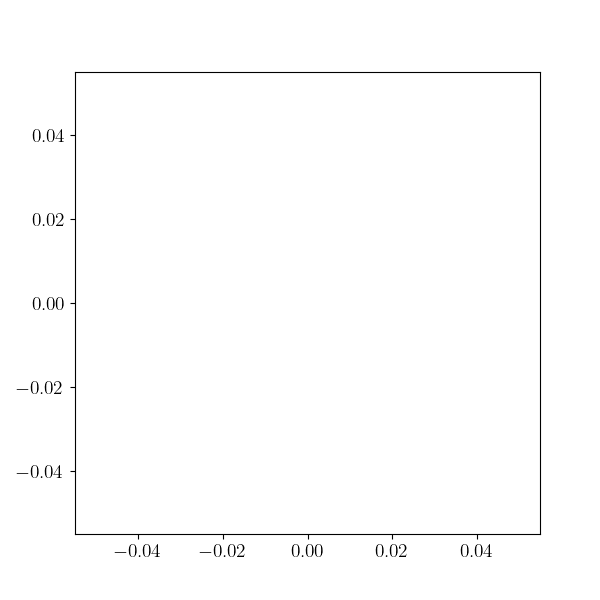

In [4]:
# Consider all homogenous agents with identical parameters
Q_x = 10
Q_y = 10
Q_theta = 0.1
Q_v = 5
R_a = 0.01
R_delta = 0.01

dt = 0.1
N = 20

L = 1
a_lim = [-0.5, 0.5]
delta_lim = [-casadi.pi/6, casadi.pi/6]
Q = [Q_x, Q_y, Q_theta, Q_v]
R = [R_a, R_delta]

n_agents = 4

aircraft_1_wp = np.array([[0.0, 0.0, 0.0],
                          [3.0, 2.5, 2.5],
                          [5.0, 5.0, 5.0],
                          [5.5, 5.5, 5.5],
                          [9.0, 7.5, 7.5],
                          [12.0, 10.0, 10.0]
                          ])

aircraft_2_wp = np.array([[0.0, 5.0, 0.0],
                          [5.5, 5.0, 2.5],
                          [8.0, 5.0, 5.0],
                          [8.5, 5.0, 5.5],
                          [11.0, 2.5, 7.5],
                          [15.0, 0.0, 10.0]
                          ])
aircraft_3_wp = np.array([[0.0, 0.0, 5.0],
                          [6.0, 2.5, 5.0],
                          [10.0, 5.0, 5.0],
                          [10.5, 5.5, 5.0],
                          [13.0, 7.5, 5.0],
                          [16.0, 10.0, 5.0]
                          ])

aircraft_4_wp = np.array([[0.0, 5.0, 10.0],
                          [9.5, 5.0, 7.5],
                          [12.0, 5.0, 5.5],
                          [12.5, 5.0, 5.0],
                          [16.5, 7.5, 2.5],
                          [20.0, 10.0, 0.0]
                          ])

wps = np.array([aircraft_1_wp, aircraft_2_wp, aircraft_3_wp, aircraft_4_wp])

agents_init_state = np.array([[0.0, 0.0, np.pi/4, 0.0], [5.0, 0.0, np.pi/2, 0.0], [0.0, 5.0, 0, 0.0], [5.0, 10.0, -np.pi/2, 0.0]])
agents_goal_state = np.array([[10.0, 10.0, np.pi/4, 0.0], [0.0, 10.0, np.pi/2 , 0.0], [10.0, 5.0, 0, 0.0], [10.0, 0.0, -np.pi/2, 0.0]])
obstacles = [(8, 2), (8, 9)]
obs_list = [obstacles]

t0_list = [0 for i in range(n_agents)]
agents = [MPC_CBF_Bicycle(agents_init_state[i], n_agents-1, dt, N, a_lim, delta_lim, L, Q, R, obstacles = obstacles, obs_diam=0.4, alpha=0.15, cbf_const=True) 
          for i in range(n_agents)]

state_0_list = [casadi.DM([
    agents_init_state[i][0], 
    agents_init_state[i][1], 
    agents_init_state[i][2],
    agents_init_state[i][3]]) for i in range(n_agents)]
u0_list = [casadi.DM.zeros((agents[i].n_controls, N)) for i in range(n_agents)]
X0_list = [casadi.repmat(state_0_list[i], 1, N + 1) for i in range(n_agents)]

u_list = [casadi.DM.zeros((agents[i].n_controls, N)) for i in range(n_agents)]
X_pred_list = [casadi.repmat(state_0_list[i], 1, N + 1) for i in range(n_agents)]
agents_state_list = [dm_to_array(X0_list[i]) for i in range(n_agents)]
agents_control_list = [dm_to_array(u0_list[i][:, 0]) for i in range(n_agents)]



max_iter = 200
wp_idx = np.array([1,1,1,1])
for t in range(max_iter):
    ref_state_list = [np.array([[wps[j][wp_idx[j],1]], 
                            [wps[j][wp_idx[j],2]], 
                            [agents_goal_state[j][2]], 
                            [agents_goal_state[j][3]]]).T for j in range(n_agents)]
    print(t, wp_idx)
    # Construct a list of neighbor states for all robots
    agent_states = np.array([agents[i].states for i in range(n_agents)])
    #print(agent_states[0][2], trajs[j]['theta'][t])
    obstacles = [(8 + t*0.004, 4 - t*0.016), (8+t*0.016, 9)]
    obs_list.append(obstacles)
    for j in range(n_agents):
        if np.sqrt((agent_states[j][0] - wps[j][wp_idx[j],1])**2 +(agent_states[j][1] - wps[j][wp_idx[j],2])**2) < 1.0 and wp_idx[j]<=4:
            if  wp_idx[j]<3:
                if j>0 and wp_idx[j-1] - wp_idx[j]>1:
                    wp_idx[j]+=1
                elif j==0:    
                    wp_idx[j]+=1
            else:
                wp_idx[j]+=1


        neighbor_states = []
        for k,agent_state in enumerate(agent_states):
            if k !=j :
                neighbor_states.append(agent_state)
        neighbor_states = np.array(neighbor_states)
        u_list[j], X_pred_list[j] = agents[j].solve(X0_list[j], u0_list[j], ref_state_list[j], t, neighbor_states, obstacles)
    for j in range(n_agents):
        agents_state_list[j] = np.dstack((agents_state_list[j], dm_to_array(X_pred_list[j])))
        agents_control_list[j] = np.dstack((agents_control_list[j], dm_to_array(u_list[j][:, 0])))
        t0_list[j], X0_list[j], u0_list[j] = agents[j].shift_timestep(dt, t0_list[j], X_pred_list[j], u_list[j])

anim_params = {
    'n_agents': n_agents,
    'ref_state_list': ref_state_list,
    'agents_init_state':agents_init_state,
    'agents_state_list':agents_state_list,
    'agents_control_list':agents_control_list,
    'num_frames':max_iter,
    'max_iter':max_iter,
    'pred_horizon':N,
    'save': False,
    'file_name':'collision_avoid.mp4',
    'obs_list': obs_list,

}

vel_var = np.zeros(4)
for i in range(n_agents):
    vel_var[i] = np.var(agents_state_list[i][3, 0, 30:-30])
print('avg_vel_var', np.mean(vel_var))

acc_var = np.zeros(4)
for i in range(n_agents):
    acc_var[i] = np.var(agents_control_list[i][0, 0, 10:-10])

print('avg_acc_var', np.mean(acc_var))

sim = animate(anim_params)
from IPython.display import HTML
HTML(sim.to_html5_video())

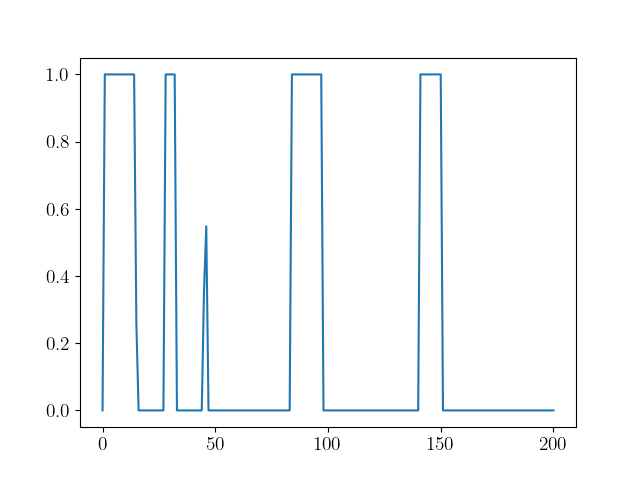

In [77]:
plt.figure()
plt.plot(agents_control_list[0][0, 0, :])
plt.show()

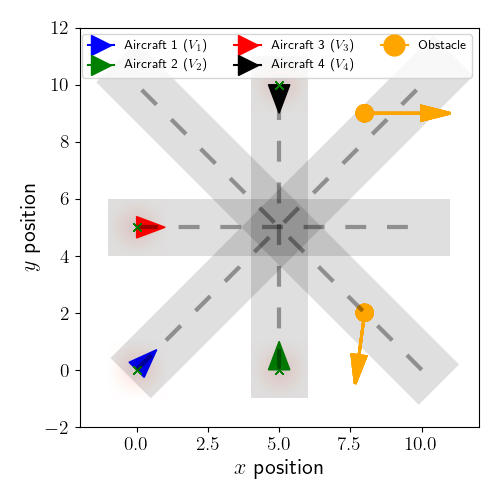

In [7]:
import matplotlib as mpl
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

mpl.rcParams['font.size'] = 14
mpl.rcParams['text.usetex'] = True

n_agents = anim_params['n_agents']
ref_state_list = anim_params['ref_state_list']
agents_init_state = anim_params['agents_init_state']
agents_state_list = anim_params['agents_state_list']
agents_control_list = anim_params['agents_control_list'] 
num_frames = anim_params['num_frames']
max_iter = anim_params['max_iter']
pred_horizon = anim_params['pred_horizon'] 
save = anim_params['save'] 
obs_list = anim_params['obs_list']

def create_triangle(state=[0,0,0], h=1.2, w=0.75, update=False):
        x, y, th = state
        triangle = np.array([
            [h, 0   ],
            [0,  w/2],
            [0, -w/2],
            [h, 0   ]
        ]).T
        rotation_matrix = np.array([
            [np.cos(th), -np.sin(th)],
            [np.sin(th),  np.cos(th)]
        ])
        coords = np.array([[x, y]]) + (rotation_matrix @ triangle).T
        if update == True:
            return coords
        else:
            return coords[:3, :]

    # Function to create a gradient-filled circle
def radial_gradient_circle(ax, center_x, center_y, radius, colormap='viridis'):
    """
    Creates a radial gradient circle.
    """
    # Create a meshgrid for the circle
    x, y = np.meshgrid(np.linspace(center_x - radius, center_x + radius, 100),
                    np.linspace(center_y - radius, center_y + radius, 100))
    # Calculate the distance from the center for each point
    r = np.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
    # Normalize the distance to be between 0 and 1
    r = np.clip(r, 0, radius) / radius
    # Create a colormap
    cmap = plt.get_cmap(colormap).reversed()
    # Map the distance to the colormap
    colors = cmap(r)
    # Plot the circle
    ax.imshow(colors, extent=[center_x - radius, center_x + radius, center_y - radius, center_y + radius], alpha=0.1)
    # Set aspect to 'equal' to ensure the circle looks circular
    ax.set_aspect('equal')

def plot_circle(ax, x, y, obs_r, color="-b"):
    circle = plt.Circle((x, y), obs_r, color='orange')
    ax.add_patch(circle)


# create figure and axes
n_agents = 4
fig, ax = plt.subplots(figsize=(5, 5))
# create lines:
#   path
path_list = []
ref_path_list = []
horizon_list = []
current_state_list = []

indexes = [400]
for i, idx in enumerate(indexes):
    for k in range(n_agents):
        # Plot Track
        plt.plot([0, 10], [5, 5], 'k--', dashes=(5, 5), lw = 3, alpha = 0.1)
        plt.plot([5, 5], [0, 10], 'k--', dashes=(5, 5), lw = 3, alpha = 0.1)
        plt.plot([0, 10], [0, 10], 'k--', dashes=(5, 5), lw = 3, alpha = 0.1)
        plt.plot([10, 0], [0, 10], 'k--', dashes=(5, 5), lw = 3, alpha = 0.1)
        
        ax.add_patch(Rectangle((-1.0,4.0),12,2,linewidth=1,facecolor='k', alpha=0.03))
        ax.add_patch(Rectangle((4.0,-1.0),2,12,linewidth=1,facecolor='k', alpha=0.03))
        ax.add_patch(Rectangle((0.5,-1.0),16,2,linewidth=1, angle = 45, facecolor='k', alpha=0.03))
        ax.add_patch(Rectangle((0.0,11.5),2,16,linewidth=1,angle=-135, facecolor='k', alpha=0.03))
        # Plot State
        x = agents_state_list[k][0, 0, i]
        y = agents_state_list[k][1, 0, i]
        th = agents_state_list[k][2, 0, i]
        current_triangle = create_triangle([x, y, th],h =1.0, w= 0.75)
        current_state = ax.fill(current_triangle[:, 0], current_triangle[:, 1], color = colors[k])
        current_state = current_state[0]
        # Plot Horizon
        x_new = agents_state_list[k][0, :, i]
        y_new = agents_state_list[k][1, :, i]
        horizon, = ax.plot(x_new, y_new, 'x-g', alpha=1)
        # # Plot Refererence Traj
        # x_ref = ref_state_list[k][:,0]
        # y_ref = ref_state_list[k][:,1]
        # horizon, = ax.plot(x_ref, y_ref, '--', color = colors[k], alpha=1)


        # Plot Obstacles 
        # if i>=140:
        for (ox, oy) in obs_list[i]:
            plot_circle(ax, ox, oy, 0.3)
        
        ax.arrow(8, 9, 2, 0, color = 'orange', lw =2,head_width=0.5, head_length=1)
        ax.arrow(8, 2, -0.2, -1.5, color = 'orange',lw=2, head_width=0.5, head_length=1)
        
        # Plot Safety
        radial_gradient_circle(ax, x, y, radius=1.0, colormap='Reds')

    


legend_elements = [Line2D([0], [0], marker='>', color=colors[i], markerfacecolor=colors[i], markersize=15, label=f'Aircraft {i+1} ($V_{i+1}$)') 
                           for i in range(n_agents)]
# legend_elements +=[Line2D([0], [0], marker='x',color='g', markerfacecolor='g', markersize=15,label='MPC Predicted Path',)]
legend_elements +=[Line2D([0], [0], marker='o',color='orange', markerfacecolor='orange', markersize=15,label='Obstacle',)]


ax.legend(handles=legend_elements, loc='upper right', ncol=3,  fontsize = 9.5)   

ax.set_xlim(-2,12)
ax.set_ylim(-2,12)
ax.set_xlabel('$x$ position', fontsize =16)
ax.set_ylabel('$y$ position', fontsize =16)       

plt.tight_layout()
plt.savefig('traj.png', dpi=300)
# plt.show()